## Indicadores de salud mental y emocional
- **Stress Level (1–10)**
Nivel de estrés percibido por el individuo, escala del 1 al 10. 
- **Family History of Anxiety**
Indica si hay antecedentes familiares de ansiedad (Yes/No).
- **Recent Major Life Event**
Si ha experimentado recientemente un evento importante (Yes/No), por ejemplo, pérdida, accidente, cambio fuerte.
- **Therapy Sessions (per month)**
Número de sesiones de terapia psicológica por mes.

## Indicadores fisiológicos
*(Estas variables se consideran altamente relacionadas con la ansiedad y algunas fuentes recomiendan excluirlas para evitar leakage.)*
- **Heart Rate (bpm)**
Frecuencia cardíaca en latidos por minuto.
- **Breathing Rate (breaths/min)**
Frecuencia respiratoria por minuto.
- **Sweating Level (1–5)**
Nivel de sudoración percibida (1 bajo – 5 alto).
- **Dizziness**
Si la persona experimenta mareos (Yes/No).
- **Medication**
Indica si la persona toma medicación (Yes/No).

## Variable objetivo
- **Anxiety Level (1–10)**
Nivel de ansiedad reportado por el individuo, de 1 (muy baja) a 10 (muy alta).

## Importando los datos

In [57]:
import pandas as pd

df_ansiety = pd.read_csv("../data/raw/enhanced_anxiety_dataset.csv")
print(df_ansiety.head())

   Age  Gender Occupation  Sleep Hours  Physical Activity (hrs/week)  \
0   29  Female     Artist          6.0                           2.7   
1   46   Other      Nurse          6.2                           5.7   
2   64    Male      Other          5.0                           3.7   
3   20  Female  Scientist          5.8                           2.8   
4   49  Female      Other          8.2                           2.3   

   Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week) Smoking  \
0                       181                                 10     Yes   
1                       200                                  8     Yes   
2                       117                                  4      No   
3                       360                                  6     Yes   
4                       247                                  4     Yes   

  Family History of Anxiety  Stress Level (1-10)  Heart Rate (bpm)  \
0                        No                   10    

In [58]:
df_ansiety.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

## Visualizando la dispersión de lo datos

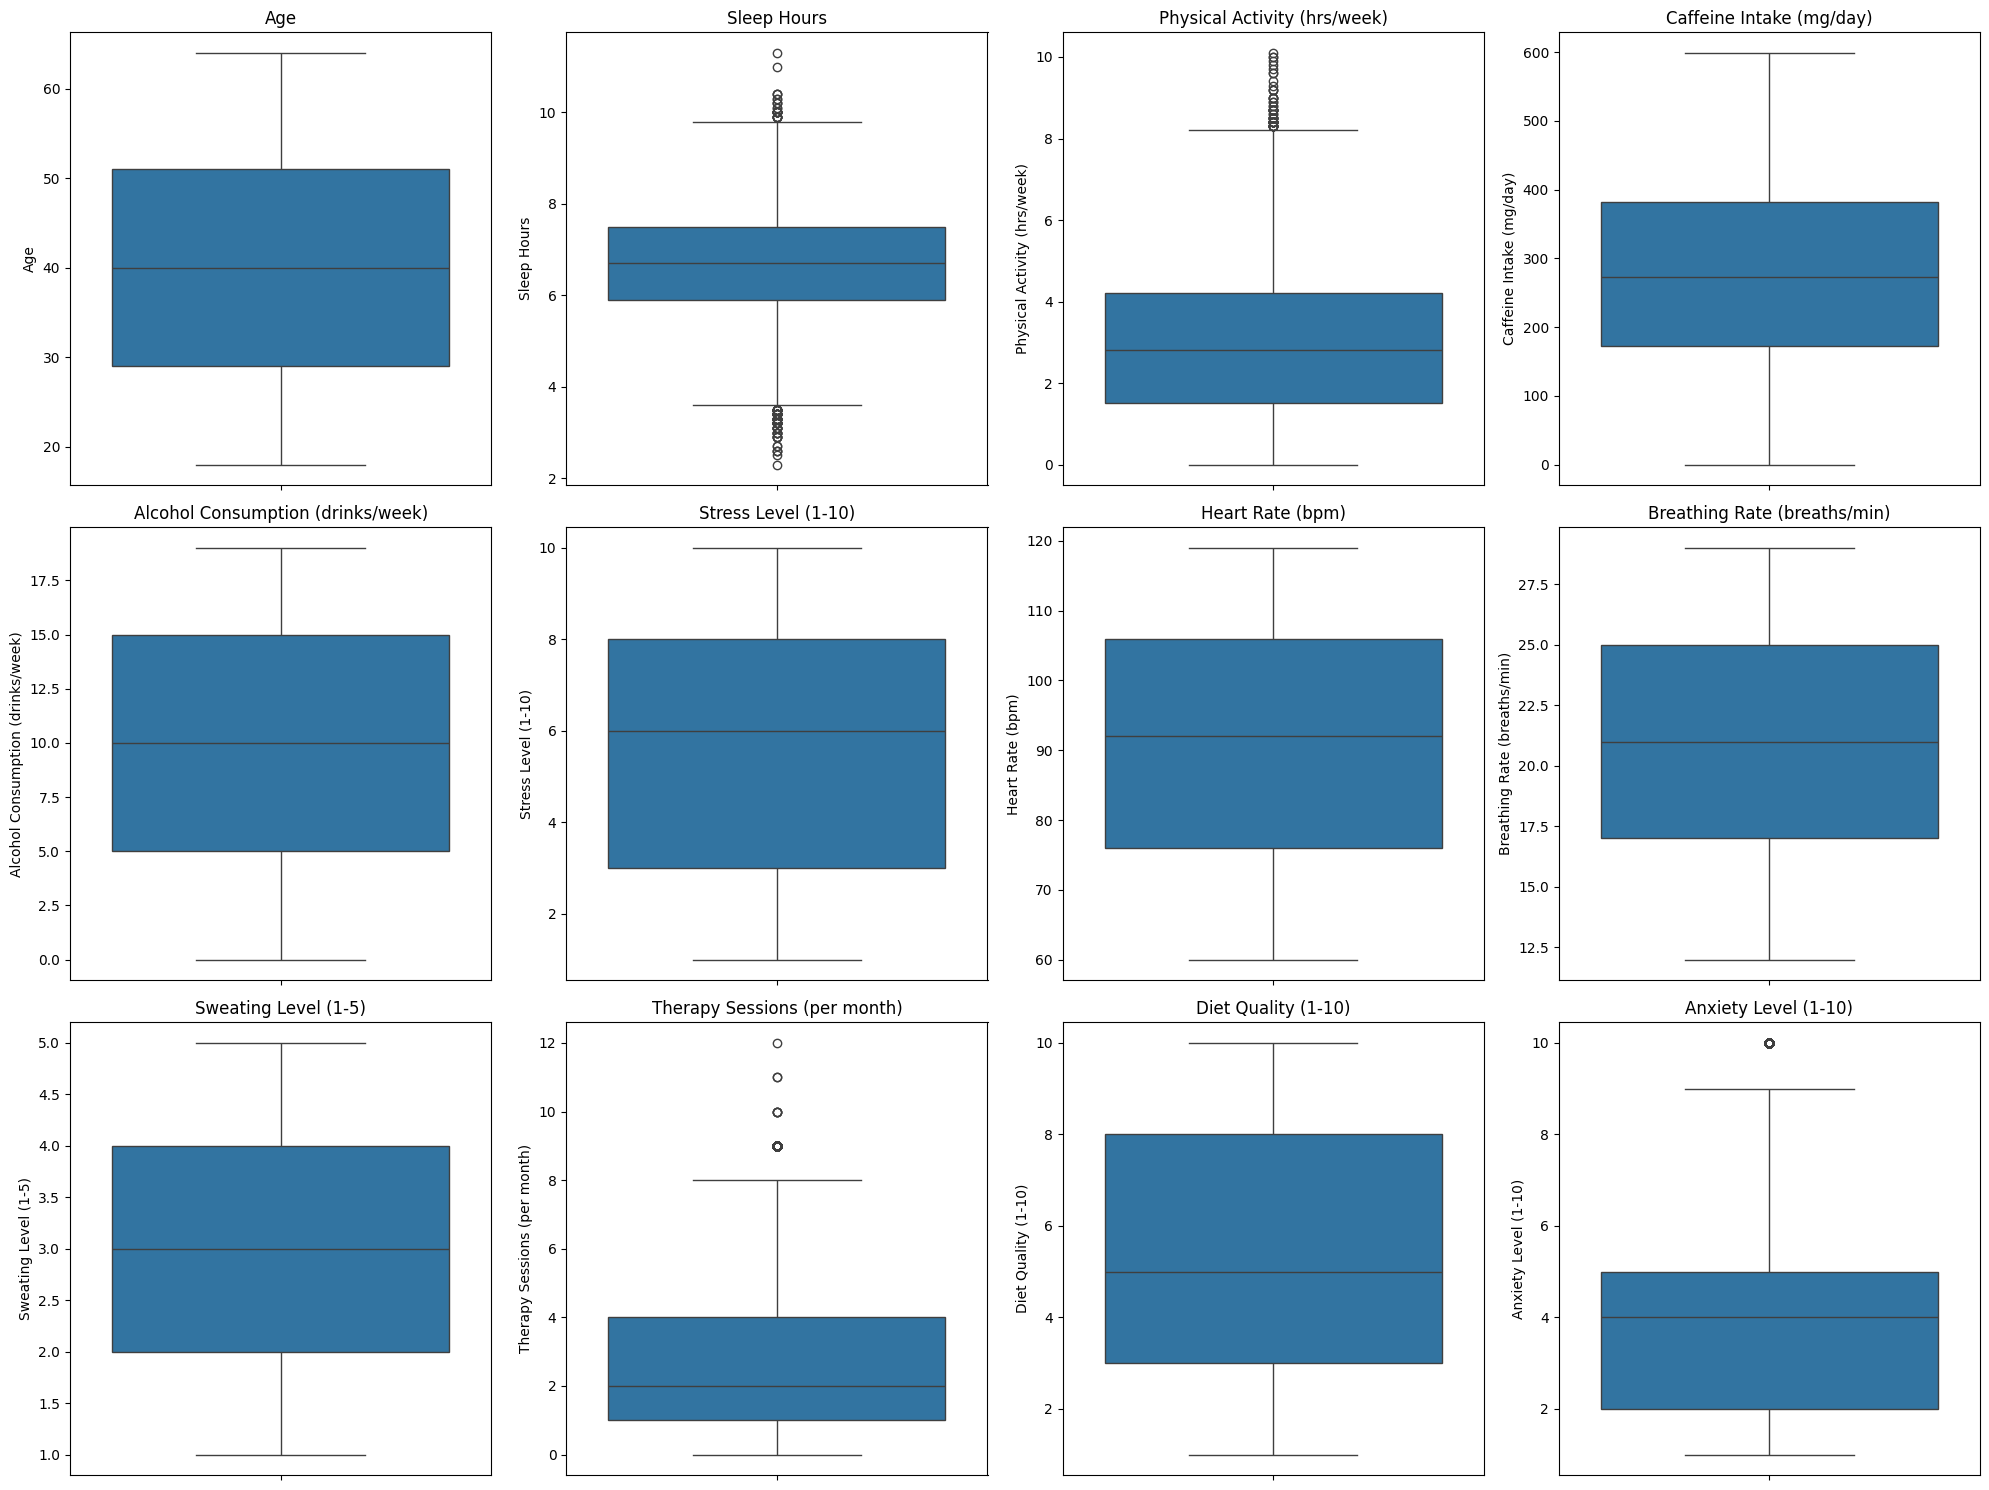

In [59]:
from typing import List, Tuple, Optional
import numpy as np
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import seaborn as sns

def graf_outliers(df: pd.DataFrame, rows: int = 1, names: Optional[List[str]] = None) -> Tuple[Figure, np.ndarray]:
    if names is None:
        names = df.select_dtypes(include=np.number).columns.tolist()
    if not names:
        raise ValueError("No presenta variables numéricas")
    plots = len(names)
    rows = rows
    columns = plots // rows + (plots % rows > 0)
    fig, ax = plt.subplots(rows, columns, figsize=(5*columns, 5*rows))
    ax = ax.ravel()
    for i, name in enumerate(names):
        sns.boxplot(y=df[name], ax=ax[i])
        ax[i].set_title(name)
    fig.tight_layout()
    return fig, ax

fig, ax = graf_outliers(df_ansiety, 3)
plt.show()

## Segmentando la variable del nivel de ansiedad

In [60]:
bins = [0, 2, 4, 6, 10]
labels = ["Muy Bajo", "Bajo", "Medio", "Alto"]

df_ansiety["anxiety_level"] = pd.cut(df_ansiety["Anxiety Level (1-10)"], bins=bins, labels=labels)
print(df_ansiety[["Anxiety Level (1-10)", "anxiety_level"]].head())

   Anxiety Level (1-10) anxiety_level
0                   5.0         Medio
1                   3.0          Bajo
2                   1.0      Muy Bajo
3                   2.0      Muy Bajo
4                   1.0      Muy Bajo


In [61]:
df_ansiety["anxiety_level"].value_counts()

anxiety_level
Bajo        4823
Muy Bajo    2795
Medio       2245
Alto        1137
Name: count, dtype: int64

## Seleccionando las profesiones que se evaluarán

In [62]:
occupations = df_ansiety["Occupation"].value_counts().sort_values(ascending=False).head(10).index.tolist()

In [63]:
df_ansiety_filtered = df_ansiety.loc[df_ansiety["Occupation"].isin(occupations)]
print(df_ansiety_filtered["Occupation"].value_counts())

Occupation
Musician      892
Artist        888
Student       878
Nurse         861
Chef          858
Doctor        842
Other         840
Freelancer    838
Engineer      833
Scientist     832
Name: count, dtype: int64


In [64]:
df_ansiety_filtered["anxiety_level"].value_counts()

anxiety_level
Bajo        3701
Muy Bajo    2212
Medio       1766
Alto         883
Name: count, dtype: int64

## Separando las muestras de entrenamiento y validación

In [65]:
from sklearn.model_selection import train_test_split

X = df_ansiety_filtered.drop(columns=["Anxiety Level (1-10)","anxiety_level","Stress Level (1-10)","Heart Rate (bpm)","Breathing Rate (breaths/min)","Sweating Level (1-5)","Dizziness"])
y = df_ansiety_filtered["anxiety_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6849, 13), (1713, 13), (6849,), (1713,))

In [66]:
y_train.value_counts()

anxiety_level
Bajo        2961
Muy Bajo    1769
Medio       1413
Alto         706
Name: count, dtype: int64

In [67]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print("Distribución original:", y_train.value_counts())
print("Distribución después del sobremuestreo:", y_train_ros.value_counts())

Distribución original: anxiety_level
Bajo        2961
Muy Bajo    1769
Medio       1413
Alto         706
Name: count, dtype: int64
Distribución después del sobremuestreo: anxiety_level
Muy Bajo    2961
Bajo        2961
Medio       2961
Alto        2961
Name: count, dtype: int64


## Definiendo el Pipeline

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

num_columns = X_train.select_dtypes(include=np.number).columns.tolist()
cat_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), num_columns),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), cat_columns)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf_rf", RandomForestClassifier(random_state=42, n_estimators=100))])

pipeline.fit(X_train_ros, y_train_ros)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['Age', 'Sleep Hours',
                                                   'Physical Activity '
                                                   '(hrs/week)',
                                                   'Caffeine Intake (mg/day)',
                                                   'Alcohol Consumption '
                                                   '(drinks/week)',
                                                   'Therapy Sessions (per '
                                                   'month)',
                                                   'Diet Quality (1-10)']),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender', 'Occupation',
                                                   'Smoking',
                                                   'Family History of Anxiety',
                                                   'Medication',
                                                   'Recent Major Life '
                                                   'Event'])])),
                ('clf_rf', RandomForestClassifier(random_state=42))])

## Realizando las predicciones con la muestra de validación

In [69]:
predict_clf = pipeline.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, predict_clf))

              precision    recall  f1-score   support

        Alto       0.97      0.90      0.94       177
        Bajo       0.49      0.70      0.57       740
       Medio       0.28      0.13      0.18       353
    Muy Bajo       0.40      0.28      0.33       443

    accuracy                           0.50      1713
   macro avg       0.53      0.50      0.51      1713
weighted avg       0.47      0.50      0.47      1713



## Métrica AUC

In [70]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba = pipeline.predict_proba(X_test)
labels_classes = pipeline.named_steps["clf_rf"].classes_
y_test_bin = label_binarize(y_test, classes=labels_classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, c in enumerate(labels_classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:,i], y_proba[:,i])
    roc_auc[c] = auc(fpr[c], tpr[c])

print("AUC por clase (OVR): ")
for c in labels_classes:
    print(f"Clase {c}: {roc_auc[c]:.2f}")

AUC por clase (OVR): 
Clase Alto: 0.96
Clase Bajo: 0.58
Clase Medio: 0.61
Clase Muy Bajo: 0.66


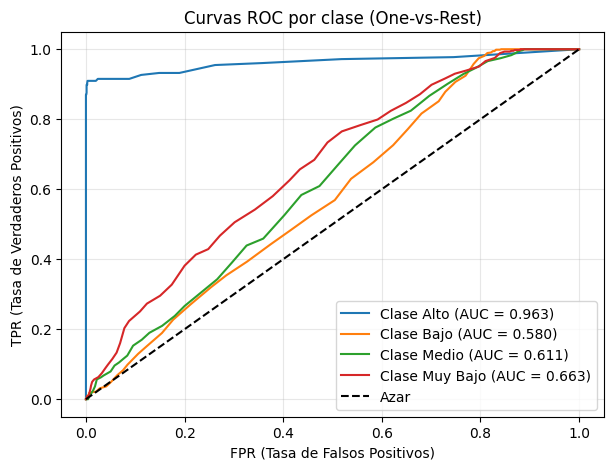

In [71]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
for c in labels_classes:
    plt.plot(fpr[c], tpr[c], label=f'Clase {c} (AUC = {roc_auc[c]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('FPR (Tasa de Falsos Positivos)')
plt.ylabel('TPR (Tasa de Verdaderos Positivos)')
plt.title('Curvas ROC por clase (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
from sklearn.metrics import precision_recall_curve, auc

umbral_optimo_pr = {}

for i, clase in enumerate(labels_classes):

    y_true = (y_test==clase).astype(int)
    scores = y_proba[:, i]

    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    pr_auc = auc(recall, precision)

    # Seleccionar el threshold que maximiza F1 en la curva PR
    f1_values = 2*(precision*recall)/(precision+recall+1e-9)
    best_idx = f1_values.argmax()
    
    umbral_optimo_pr[clase] = thresholds[best_idx]

umbral_optimo_pr

{'Alto': np.float64(0.44),
 'Bajo': np.float64(0.26),
 'Medio': np.float64(0.21),
 'Muy Bajo': np.float64(0.26)}